<a href="https://colab.research.google.com/github/Otavio8888/investment_funds_CVM/blob/data_extraction/fundos_CVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXTRAÇÃO documentos - INFORME MENSAL ESTRUTURADO da CVM no Fundos.net após 2016

In [ ]:
import requests
import pandas as pd
import os
import xml.etree.ElementTree as ET
import base64
import re

# --- Configurações ---
ID_DOCUMENTO = "20513"
URL_DOWNLOAD = f"https://fnet.bmfbovespa.com.br/fnet/publico/downloadDocumento?id={ID_DOCUMENTO}"
PASTA_DOWNLOAD = "fnet_extracao_unica"
NOME_ARQUIVO_BASE = f"dados_fnet_id_{ID_DOCUMENTO}.csv"

os.makedirs(PASTA_DOWNLOAD, exist_ok=True)

# Funções de Parsing (Otimizadas)
def clean_tag(tag):
    return tag.split('}')[-1]

def parse_xml_recursively(element, prefix=''):
    data = {}
    for child in element:
        tag = clean_tag(child.tag)
        current_prefix = f"{prefix}_{tag}" if prefix else tag

        if child.text and child.text.strip():
            data[current_prefix] = child.text.strip()

        for key, value in child.attrib.items():
            data[f"{current_prefix}_{clean_tag(key)}"] = value

        sub_data = parse_xml_recursively(child, prefix=current_prefix)
        data.update(sub_data)

    return data

print(f"--- 1. Recriando Arquivo Base (ID: {ID_DOCUMENTO}) ---")

try:
    # A) Download e Decodificação Base64
    response = requests.get(URL_DOWNLOAD, timeout=30)
    response.raise_for_status()
    base64_content = response.text.strip()
    xml_decoded_bytes = base64.b64decode(base64_content)
    xml_decoded_content = xml_decoded_bytes.decode('utf-8')

    # B) Preparação e Parsing do XML
    xml_to_parse = re.sub(r'xmlns:xsi="[^"]*"', '', xml_decoded_content)
    xml_to_parse = re.sub(r'xsi:nil="[^"]*"', '', xml_to_parse)

    root = ET.fromstring(xml_to_parse)
    registro_unico = parse_xml_recursively(root, prefix=clean_tag(root.tag))

    if registro_unico:
        registro_unico['Fonte_ID'] = ID_DOCUMENTO
        df_final = pd.DataFrame([registro_unico])

        # C) Salvamento do CSV
        df_final.to_csv(NOME_ARQUIVO_BASE, index=False, encoding='utf-8')
        print(f"   [OK] Arquivo base salvo com sucesso: '{NOME_ARQUIVO_BASE}'")
    else:
        print("   [ERRO] Falha na extração de dados do XML.")

except Exception as e:
    print(f"   [ERRO FATAL NA EXTRAÇÃO] Ocorreu um erro: {e}")

--- 1. Recriando Arquivo Base (ID: 20513) ---
   [OK] Arquivo base salvo com sucesso: 'dados_fnet_id_20513.csv'


# visualizar os dados

In [ ]:
import pandas as pd
import os

# Define o nome do arquivo que foi salvo
NOME_ARQUIVO_CSV = 'dados_fnet_id_20513.csv'

print(f"--- Carregando o arquivo {NOME_ARQUIVO_CSV} para inspeção ---")

try:
    # 1. Carrega o CSV de volta para um novo DataFrame
    df_inspecao = pd.read_csv(NOME_ARQUIVO_CSV)

    # 2. Configurações de Exibição do Pandas para ver todas as colunas
    # (Se você estiver em um ambiente como Jupyter ou Google Colab, isso é essencial)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', 50)
    pd.set_option('display.width', 1000)

    print("\n[SUCESSO] DataFrame carregado.")
    print(f"Dimensões do DataFrame: {df_inspecao.shape[0]} linhas x {df_inspecao.shape[1]} colunas")

    # 3. Identifica e exibe as colunas mais relevantes para a perícia

    # Lista de palavras-chave para identificar colunas financeiras/identificadoras
    keywords = ['CNPJFundo', 'NomeFundo', 'PatrimonioLiquido', 'Ativo', 'ValorPatrCotas', 'Fonte_ID', 'Competencia']

    colunas_relevantes = [
        col for col in df_inspecao.columns
        if any(keyword in col for keyword in keywords)
    ]

    print("\nInformações Chave do DataFrame (Transpostas para melhor leitura):")

    # Usa a transposição (.T) para exibir as colunas na vertical, facilitando a leitura
    # dos nomes longos e dos valores de uma única linha.
    print(df_inspecao[colunas_relevantes].T)

    # Exibe o tipo de dado de algumas colunas (para identificar strings numéricas)
    print("\nTipos de Dados Chave:")
    print(df_inspecao[colunas_relevantes].dtypes)


except FileNotFoundError:
    print(f"\n[ERRO] Arquivo '{NOME_ARQUIVO_CSV}' não encontrado.")
    print("Verifique se o arquivo está na mesma pasta onde o código Python está sendo executado.")
except Exception as e:
    print(f"\n[ERRO] Ocorreu um erro ao ler o CSV: {e}")

--- Carregando o arquivo dados_fnet_id_20513.csv para inspeção ---

[SUCESSO] DataFrame carregado.
Dimensões do DataFrame: 1 linhas x 107 colunas

Informações Chave do DataFrame (Transpostas para melhor leitura):
                                                                                            0
DadosEconomicoFinanceiros_DadosGerais_NomeFundo     AQUILLA FUNDO DE INVESTIMENTO IMOBILIÁRIO
DadosEconomicoFinanceiros_DadosGerais_CNPJFundo                                13555918000149
DadosEconomicoFinanceiros_DadosGerais_Competencia                                  2017-11-01
DadosEconomicoFinanceiros_InformeMensal_Resumo_...                               182587403.67
DadosEconomicoFinanceiros_InformeMensal_Resumo_...                               181900735.43
DadosEconomicoFinanceiros_InformeMensal_Resumo_...                                 1857.37344
DadosEconomicoFinanceiros_InformeMensal_Informa...                                          0
DadosEconomicoFinanceiros_InformeMe

#limpeza de dados

In [ ]:
import pandas as pd
import numpy as np # Importado para usar pd.isna e np.isclose

# Define o nome do arquivo que foi salvo
NOME_ARQUIVO_CSV = 'dados_fnet_id_20513.csv'
PREFIXO_A_REMOVER = 'DadosEconomicoFinanceiros_InformeMensal_Informacoes'
NOME_ARQUIVO_FILTRADO = 'dados_fnet_id_20513_filtrado_zero.csv' # Novo nome para o arquivo de saída

print(f"--- 1. Carregando e Limpando o DataFrame: {NOME_ARQUIVO_CSV} ---")

try:
    # Carrega o DataFrame
    df = pd.read_csv(NOME_ARQUIVO_CSV)

    # Define as opções de exibição para melhor visualização
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    # 2. Executa a Limpeza dos Nomes das Colunas (Código Original)
    mapeamento_colunas = {}

    for coluna_antiga in df.columns:
        if coluna_antiga.startswith(PREFIXO_A_REMOVER):
            coluna_nova = coluna_antiga.replace(PREFIXO_A_REMOVER, '').lstrip('_')
            mapeamento_colunas[coluna_antiga] = coluna_nova
        else:
            mapeamento_colunas[coluna_antiga] = coluna_antiga

    df.rename(columns=mapeamento_colunas, inplace=True)
    print("\n[SUCESSO] Nomes de colunas limpos.")

    # --- NOVO CÓDIGO PARA FILTRAGEM DE ZERO/NAN ---

    # 2.1 Conversão de Tipos para Numérico (Essencial para filtrar 0 e NaN)
    df_processado = df.copy()

    for col in df_processado.columns:
        # Tenta converter para float. Erros (colunas de texto) são forçados a NaN.
        # Isso garante que 0 e valores numéricos sejam tratados corretamente.
        try:
            df_processado[col] = pd.to_numeric(df_processado[col], errors='coerce')
        except:
            pass

    # 2.2 Exclusão de Colunas com Valor Zero ou NaN
    cols_a_manter = []

    # Como o DataFrame tem apenas 1 linha por documento, verificamos essa linha (iloc[0])
    for col in df_processado.columns:
        if pd.api.types.is_numeric_dtype(df_processado[col]):
            valor = df_processado.iloc[0][col]

            # Mantém a coluna se o valor não for NaN E não for zero (np.isclose é para floats)
            if not pd.isna(valor) and not np.isclose(valor, 0.0, atol=1e-9):
                cols_a_manter.append(col)
        else:
            # Mantém colunas não-numéricas (texto de descrição, CNPJ, Fonte_ID)
            cols_a_manter.append(col)

    df_filtrado = df_processado[cols_a_manter].copy()

    # Contagem das colunas removidas
    colunas_removidas = len(df.columns) - len(df_filtrado.columns)
    print(f"[OK] {colunas_removidas} colunas com valor 0 ou NaN foram removidas.")

    # 3. Exibe as Colunas Afetadas (para confirmação)
    print("\n--- AMOSTRA DAS COLUNAS FILTRADAS ---")

    # Mostra colunas que começam com 'Ativo', 'Passivo' ou 'ValoresReceber'
    colunas_filtradas_amostra = [
        col for col in df_filtrado.columns
        if any(keyword in col for keyword in ['Ativo', 'Passivo', 'ValoresReceber'])
    ]

    print(df_filtrado[colunas_filtradas_amostra].T)

    # 4. Salva o DataFrame Filtrado
    df_filtrado.to_csv(NOME_ARQUIVO_FILTRADO, index=False, encoding='utf-8')
    print(f"\nDataFrame filtrado (sem 0/NaN) salvo em: '{NOME_ARQUIVO_FILTRADO}'")


except FileNotFoundError:
    print(f"\n[ERRO] Arquivo '{NOME_ARQUIVO_CSV}' não encontrado.")
    print("Certifique-se de que o arquivo está no diretório de execução.")
except Exception as e:
    print(f"\n[ERRO] Ocorreu um erro durante a limpeza: {e}")

--- 1. Carregando e Limpando o DataFrame: dados_fnet_id_20513.csv ---

[SUCESSO] Nomes de colunas limpos.
[OK] 77 colunas com valor 0 ou NaN foram removidas.

--- AMOSTRA DAS COLUNAS FILTRADAS ---
                                                               0
DadosEconomicoFinanceiros_InformeMensal_Resumo_...  1.825874e+08
Ativo_TotalInvestido_total                          1.825845e+08
Ativo_TotalInvestido_DireitosBensImoveis_total      1.010140e+07
Ativo_TotalInvestido_DireitosBensImoveis_Imovei...  1.010140e+07
Ativo_TotalInvestido_FII                            1.365867e+08
Ativo_TotalInvestido_OutrasCotasFI                  1.550143e+04
Ativo_TotalInvestido_CotasSociedadesAtivFII         3.588086e+07
Ativo_ValoresReceber_total                          2.929010e+03
Ativo_ValoresReceber_OutrosValores                  2.929010e+03
Passivo_TxAdministracaoPagar                        5.780239e+04
Passivo_OutrosValoresPagar                          6.288658e+05
Passivo_TotalPassivo   

cada ano possui um ID que achei no dev tools da url

In [ ]:
import requests
import pandas as pd
import os
import xml.etree.ElementTree as ET
import base64
import time
import re
import numpy as np

# --- 1. Configurações Globais ---
CNPJ_FUNDO = "13555918000149"
PASTA_DOWNLOAD = "fnet_historico_dezembro_manual"
NOME_ARQUIVO_FINAL = f"fnet_consolidado_subcontas_sem_zero_{CNPJ_FUNDO}_FINAL.csv"

# Mapeamento Manual de IDs (2017-2024)
MAPA_IDS = {
    '2017': '20513',
    '2018': '39186',
    '2019': '72000',
    '2020': '138084',
    '2021': '236471',
    '2022': '385080',
    '2023': '580647',
    '2024': '815605'
}

URL_DOWNLOAD_BASE = "https://fnet.bmfbovespa.com.br/fnet/publico/downloadDocumento?id="

# Prefixos para Limpeza de Colunas
PREFIXO_A_REMOVER_1 = 'DadosEconomicoFinanceiros_InformeMensal_Informacoes'
PREFIXO_A_REMOVER_2 = 'DadosEconomicoFinanceiros_InformeMensal_'
PREFIXO_A_REMOVER_3 = 'DadosEconomicoFinanceiros_'

os.makedirs(PASTA_DOWNLOAD, exist_ok=True)

# --- 2. Funções de Parsing e Limpeza ---

def clean_tag(tag): return tag.split('}')[-1]

def parse_xml_recursively(element, prefix=''):
    data = {}
    for child in element:
        tag = clean_tag(child.tag)
        current_prefix = f"{prefix}_{tag}" if prefix else tag
        if child.text and child.text.strip(): data[current_prefix] = child.text.strip()
        for key, value in child.attrib.items(): data[f"{current_prefix}_{clean_tag(key)}"] = value
        sub_data = parse_xml_recursively(child, prefix=current_prefix)
        data.update(sub_data)
    return data

def limpar_nomes_colunas(df):
    mapeamento_colunas = {}
    for coluna_antiga in df.columns:
        coluna_nova = coluna_antiga

        # 1. Remoção do prefixo Informacoes (Ex: Ativo_TotalInvestido...)
        if coluna_nova.startswith(PREFIXO_A_REMOVER_1): coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_1, 'Info_')
        # 2. Remoção do prefixo Mensal (Ex: Resumo_Ativo)
        elif coluna_nova.startswith(PREFIXO_A_REMOVER_2): coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_2, 'Mensal_')
        # 3. Remoção do prefixo raiz
        elif coluna_nova.startswith(PREFIXO_A_REMOVER_3): coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_3, '')

        coluna_nova = coluna_nova.lstrip('_')

        # Manter 'Gerais' para as colunas de identificação
        if coluna_nova.startswith('DadosGerais_'): coluna_nova = coluna_nova.replace('DadosGerais_', 'Gerais_')

        mapeamento_colunas[coluna_antiga] = coluna_nova

    df.rename(columns=mapeamento_colunas, inplace=True)
    return df


# --- 3. Loop de Coleta e Consolidação ---
print("--- 1. INICIANDO COLETA HISTÓRICA DE SUBCONTAS (2017-2024) ---")

dados_finais = []

for ano, id_doc in MAPA_IDS.items():
    nome_ref = f"Ref_{ano}_ID_{id_doc}"
    print(f"\n-> Processando Ano: {ano} | ID: {id_doc}")
    url_download_doc = URL_DOWNLOAD_BASE + id_doc

    try:
        # A) Download, Decodificação e Parsagem
        response = requests.get(url_download_doc, timeout=30)
        response.raise_for_status()
        base64_content = response.text.strip()
        xml_decoded_bytes = base64.b64decode(base64_content)
        xml_decoded_content = xml_decoded_bytes.decode('utf-8')
        xml_to_parse = re.sub(r'xmlns:xsi="[^"]*"', '', xml_decoded_content)
        xml_to_parse = re.sub(r'xsi:nil="[^"]*"', '', xml_to_parse)
        root = ET.fromstring(xml_to_parse)
        registro_unico = parse_xml_recursively(root, prefix=clean_tag(root.tag))

        if registro_unico:
            registro_unico['Fonte_ID'] = id_doc
            registro_unico['Ano_Referencia'] = ano
            df_registro = pd.DataFrame([registro_unico])
            df_registro = limpar_nomes_colunas(df_registro)

            # --- FILTRAGEM DE COLUNAS DE SOMA (Foca no Detalhe) ---
            # Remove totais consolidados e Totais percentuais (para manter apenas os subitens)
            cols_a_remover_soma = [
                col for col in df_registro.columns
                if (col.endswith('_total') or col.endswith('_total_') or 'Mensal_Resumo_' in col)
                   and 'PatrimonioLiquido' not in col # Mantemos o PL para referência
            ]

            # Remove o Ativo/Passivo Principal (Total)
            cols_a_remover_soma.extend([col for col in df_registro.columns if col.endswith('_Ativo') or col.endswith('_Passivo')])
            cols_a_remover_soma = [col for col in cols_a_remover_soma if col not in ['Mensal_Resumo_PatrimonioLiquido', 'Mensal_Resumo_Ativo', 'Mensal_TotalPassivo']] # Mantém os Totais Principais

            # Adiciona ao consolidado (após a remoção de colunas de soma)
            dados_finais.append(df_registro.drop(columns=cols_a_remover_soma, errors='ignore'))
            print("   [OK] Extração e pré-limpeza de totais concluídas.")

    except Exception as e:
        print(f"   [ERRO] Falha no processamento do ID {id_doc}: {e}")
    time.sleep(0.5)

# --- 4. Resultado Final (Consolidação e Filtragem Final de Zero/NaN) ---

if dados_finais:
    df_consolidado = pd.concat(dados_finais, ignore_index=True)

    # B) Conversão para Numérico (Essencial para a filtragem)
    for col in df_consolidado.columns:
        if any(keyword in col for keyword in ['Ativo', 'Passivo', 'PatrimonioLiquido', 'ValorPatrCotas', 'total']):
            try:
                df_consolidado[col] = pd.to_numeric(df_consolidado[col], errors='coerce')
            except:
                pass

    # --- FILTRAGEM DE COLUNAS ZERO/NAN NO CONSOLIDADO (Chave do Pedido) ---

    cols_a_manter = []

    for col in df_consolidado.columns:
        if pd.api.types.is_numeric_dtype(df_consolidado[col]):
            # Verifica se QUALQUER valor na coluna é diferente de zero ou não é NaN
            # Mantém a coluna se a soma de valores absolutos for > 0 ou se houver pelo menos um valor não-NaN.
            is_zero_across_all_years = np.allclose(df_consolidado[col].fillna(0), 0, atol=1e-9)
            has_non_nan_value = df_consolidado[col].notna().any()

            if has_non_nan_value and not is_zero_across_all_years:
                cols_a_manter.append(col)
        else:
            # Mantém colunas não-numéricas (texto, identificação)
            cols_a_manter.append(col)

    df_final = df_consolidado[cols_a_manter].copy()

    print("\n" + "="*80)
    print(f"--- PROCESSO CONCLUÍDO. REGISTROS FILTRADOS: {len(df_final.columns)} COLUNAS ---")

    # Salva o resultado final (sem formatação para manter os números como float)
    df_final.to_csv(NOME_ARQUIVO_FINAL, index=False, encoding='utf-8')
    print(f"\nDataFrame final (subcontas sem zero) salvo em: '{NOME_ARQUIVO_FINAL}'")

    # 5. Visualização (Apenas os subitens relevantes)
    colunas_referencia = ['Ano_Referencia', 'Gerais_NomeFundo', 'Mensal_Resumo_PatrimonioLiquido']
    colunas_subitens_filtradas = [col for col in df_final.columns if any(k in col for k in ['Info_', 'Passivo_', 'Receber_', 'Inv_'])]

    colunas_para_exibir = colunas_referencia + colunas_subitens_filtradas
    colunas_presentes = [col for col in colunas_para_exibir if col in df_final.columns]

    print("\n--- DETALHAMENTO DAS CONTAS COM MOVIMENTAÇÃO (2016-2024) ---")

    # Exibe a transposição para ver a evolução de cada subitem em todos os anos.
    df_visual = df_final[colunas_presentes].sort_values(by='Ano_Referencia').set_index('Ano_Referencia')

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    print(df_visual.T)

else:
    print("\n[AVISO] A coleta não gerou dados. Verifique os IDs.")

--- 1. INICIANDO COLETA HISTÓRICA DE SUBCONTAS (2017-2024) ---

-> Processando Ano: 2017 | ID: 20513
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2018 | ID: 39186
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2019 | ID: 72000
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2020 | ID: 138084
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2021 | ID: 236471
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2022 | ID: 385080
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2023 | ID: 580647
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2024 | ID: 815605
   [OK] Extração e pré-limpeza de totais concluídas.

--- PROCESSO CONCLUÍDO. REGISTROS FILTRADOS: 66 COLUNAS ---

DataFrame final (subcontas sem zero) salvo em: 'fnet_consolidado_subcontas_sem_zero_13555918000149_FINAL.csv'

--- DETALHAMENTO DAS CONTAS COM

In [ ]:
import requests
import pandas as pd
import os
import xml.etree.ElementTree as ET
import base64
import time
import re
import numpy as np

# --- 1. Configurações Globais ---
CNPJ_FUNDO = "13555918000149"
PASTA_DOWNLOAD = "fnet_historico_dezembro_manual"
NOME_ARQUIVO_FINAL = f"fnet_consolidado_subcontas_sem_zero_{CNPJ_FUNDO}_FINAL.csv"

# Mapeamento Manual de IDs (2016-2024)
MAPA_IDS = {
    '2016': '11131',
    '2017': '20513',
    '2018': '39186',
    '2019': '72000',
    '2020': '138084',
    '2021': '236471',
    '2022': '385080',
    '2023': '580647',
    '2024': '815605'
}

URL_DOWNLOAD_BASE = "https://fnet.bmfbovespa.com.br/fnet/publico/downloadDocumento?id="

# Prefixos para Limpeza de Colunas
PREFIXO_A_REMOVER_1 = 'DadosEconomicoFinanceiros_InformeMensal_Informacoes'
PREFIXO_A_REMOVER_2 = 'DadosEconomicoFinanceiros_InformeMensal_'
PREFIXO_A_REMOVER_3 = 'DadosEconomicoFinanceiros_'

# NOVOS PREFIXOS A SEREM REMOVIDOS
PREFIXO_A_REMOVER_4 = 'Info_Ativo_'
PREFIXO_A_REMOVER_5 = 'Info_Passivo_'


os.makedirs(PASTA_DOWNLOAD, exist_ok=True)

# --- 2. Funções de Parsing e Limpeza ---

def clean_tag(tag): return tag.split('}')[-1]

def parse_xml_recursively(element, prefix=''):
    data = {}
    for child in element:
        tag = clean_tag(child.tag)
        current_prefix = f"{prefix}_{tag}" if prefix else tag
        if child.text and child.text.strip(): data[current_prefix] = child.text.strip()
        for key, value in child.attrib.items(): data[f"{current_prefix}_{clean_tag(key)}"] = value
        sub_data = parse_xml_recursively(child, prefix=current_prefix)
        data.update(sub_data)
    return data

def limpar_nomes_colunas(df):
    """Aplica a remoção de todos os prefixos longos, incluindo Info_Ativo_ e Info_Passivo_."""
    mapeamento_colunas = {}
    for coluna_antiga in df.columns:
        coluna_nova = coluna_antiga

        # 1. Remoção do prefixo Informacoes
        if coluna_nova.startswith(PREFIXO_A_REMOVER_1): coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_1, 'Info_')
        # 2. Remoção do prefixo Mensal
        elif coluna_nova.startswith(PREFIXO_A_REMOVER_2): coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_2, 'Mensal_')
        # 3. Remoção do prefixo raiz
        elif coluna_nova.startswith(PREFIXO_A_REMOVER_3): coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_3, '')

        # 4. REMOÇÃO DOS NOVOS PREFIXOS (Simplifica o detalhe da subconta)
        if coluna_nova.startswith(PREFIXO_A_REMOVER_4):
            coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_4, 'Ativo_')
        elif coluna_nova.startswith(PREFIXO_A_REMOVER_5):
            coluna_nova = coluna_nova.replace(PREFIXO_A_REMOVER_5, 'Passivo_')

        coluna_nova = coluna_nova.lstrip('_')

        # Manter 'Gerais' para as colunas de identificação
        if coluna_nova.startswith('DadosGerais_'): coluna_nova = coluna_nova.replace('DadosGerais_', 'Gerais_')

        mapeamento_colunas[coluna_antiga] = coluna_nova

    df.rename(columns=mapeamento_colunas, inplace=True)
    return df


# --- 3. Loop de Coleta e Consolidação ---
print("--- 1. INICIANDO COLETA HISTÓRICA DE SUBCONTAS (2016-2024) ---")

dados_finais = []

for ano, id_doc in MAPA_IDS.items():
    nome_ref = f"Ref_{ano}_ID_{id_doc}"
    print(f"\n-> Processando Ano: {ano} | ID: {id_doc}")
    url_download_doc = URL_DOWNLOAD_BASE + id_doc

    try:
        # A) Download e Parsagem
        response = requests.get(url_download_doc, timeout=30)
        response.raise_for_status()
        base64_content = response.text.strip()
        xml_decoded_bytes = base64.b64decode(base64_content)
        xml_decoded_content = xml_decoded_bytes.decode('utf-8')
        xml_to_parse = re.sub(r'xmlns:xsi="[^"]*"', '', xml_decoded_content)
        xml_to_parse = re.sub(r'xsi:nil="[^"]*"', '', xml_to_parse)
        root = ET.fromstring(xml_to_parse)
        registro_unico = parse_xml_recursively(root, prefix=clean_tag(root.tag))

        if registro_unico:
            registro_unico['Fonte_ID'] = id_doc
            registro_unico['Ano_Referencia'] = ano
            df_registro = pd.DataFrame([registro_unico])
            df_registro = limpar_nomes_colunas(df_registro)

            # --- FILTRAGEM DE COLUNAS DE SOMA (Foca no Detalhe) ---

            cols_a_remover_soma = [
                col for col in df_registro.columns
                if (col.endswith('_total') or col.endswith('_total_') or 'Mensal_Resumo_' in col)
                   and 'PatrimonioLiquido' not in col # Mantemos o PL para referência
            ]

            # Remove o Ativo/Passivo Principal (Total) e outras somas
            cols_a_remover_soma.extend([col for col in df_registro.columns if col.endswith('_Ativo') or col.endswith('_Passivo')])
            cols_a_remover_soma = [col for col in cols_a_remover_soma if col not in ['Mensal_Resumo_PatrimonioLiquido', 'Mensal_Resumo_Ativo', 'Mensal_TotalPassivo']]

            # Linha 131 Corrigida: Garantimos que o comando esteja completo
            dados_finais.append(df_registro.drop(columns=cols_a_remover_soma, errors='ignore'))
            print("   [OK] Extração e pré-limpeza de totais concluídas.")

    except Exception as e:
        print(f"   [ERRO] Falha no processamento do ID {id_doc}: {e}")
    time.sleep(0.5)

# --- 4. Resultado Final (Consolidação e Filtragem Final de Zero/NaN) ---

if dados_finais:
    df_consolidado = pd.concat(dados_finais, ignore_index=True)

    # B) Conversão para Numérico
    for col in df_consolidado.columns:
        if any(keyword in col for keyword in ['Ativo', 'Passivo', 'PatrimonioLiquido', 'ValorPatrCotas', 'total']):
            try:
                df_consolidado[col] = pd.to_numeric(df_consolidado[col], errors='coerce')
            except:
                pass

    # --- FILTRAGEM DE COLUNAS ZERO/NAN NO CONSOLIDADO ---

    cols_a_manter = []

    for col in df_consolidado.columns:
        if pd.api.types.is_numeric_dtype(df_consolidado[col]):
            is_zero_across_all_years = np.allclose(df_consolidado[col].fillna(0), 0, atol=1e-9)
            has_non_nan_value = df_consolidado[col].notna().any()

            if has_non_nan_value and not is_zero_across_all_years:
                cols_a_manter.append(col)
        else:
            cols_a_manter.append(col)

    df_final = df_consolidado[cols_a_manter].copy()

    print("\n" + "="*80)
    print(f"--- PROCESSO CONCLUÍDO. REGISTROS FILTRADOS: {len(df_final.columns)} COLUNAS ---")

    # Salva o resultado final (sem formatação para manter os números como float)
    df_final.to_csv(NOME_ARQUIVO_FINAL, index=False, encoding='utf-8')
    print(f"\nDataFrame final (subcontas sem zero) salvo em: '{NOME_ARQUIVO_FINAL}'")

    # 5. Visualização (Apenas os subitens relevantes)

    colunas_referencia = ['Ano_Referencia', 'Gerais_NomeFundo', 'Mensal_Resumo_PatrimonioLiquido']
    # Colunas que representam subitens após a nova limpeza
    colunas_subitens_filtradas = [col for col in df_final.columns if any(k in col for k in ['Ativo_', 'Passivo_', 'Receber_', 'Inv_'])]

    colunas_para_exibir = colunas_referencia + colunas_subitens_filtradas
    colunas_presentes = [col for col in colunas_para_exibir if col in df_final.columns]

    print("\n--- DETALHAMENTO DAS CONTAS COM MOVIMENTAÇÃO (2016-2024) ---")

    df_visual = df_final[colunas_presentes].sort_values(by='Ano_Referencia').set_index('Ano_Referencia')

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    print(df_visual.T)

else:
    print("\n[AVISO] A coleta não gerou dados. Verifique os IDs.")

--- 1. INICIANDO COLETA HISTÓRICA DE SUBCONTAS (2016-2024) ---

-> Processando Ano: 2016 | ID: 11131
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2017 | ID: 20513
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2018 | ID: 39186
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2019 | ID: 72000
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2020 | ID: 138084
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2021 | ID: 236471
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2022 | ID: 385080
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2023 | ID: 580647
   [OK] Extração e pré-limpeza de totais concluídas.

-> Processando Ano: 2024 | ID: 815605
   [OK] Extração e pré-limpeza de totais concluídas.

--- PROCESSO CONCLUÍDO. REGISTROS FILTRADOS: 115 COLUNAS ---

DataFrame final (subcontas sem zero) salvo em: 'fn

salvar em csv

In [ ]:
NOME_ARQUIVO_VISUAL_CSV = f"fnet_subcontas_visual_transposto_{CNPJ_FUNDO}.csv"
df_visual.to_csv(NOME_ARQUIVO_VISUAL_CSV, index=True, encoding='utf-8')
print(f"DataFrame df_visual (transposto) salvo em: '{NOME_ARQUIVO_VISUAL_CSV}'")

DataFrame df_visual (transposto) salvo em: 'fnet_subcontas_visual_transposto_13555918000149.csv'


In [ ]:
import pandas as pd
import numpy as np

# Nome do arquivo CSV do df_visual transposto
NOME_ARQUIVO_VISUAL_CSV = f"fnet_subcontas_visual_transposto_{CNPJ_FUNDO}.csv"
NOME_ARQUIVO_DIFERENCA = f"fnet_subcontas_variacao_{CNPJ_FUNDO}.csv"

print(f"--- Calculando a diferença ano a ano do arquivo: {NOME_ARQUIVO_VISUAL_CSV} ---")

try:
    # Carrega o DataFrame df_visual transposto
    # A primeira coluna se torna o índice automaticamente ao carregar um CSV salvo com index=True
    df_visual_reloaded = pd.read_csv(NOME_ARQUIVO_VISUAL_CSV, index_col=0)

    # Identifica as colunas numéricas para o cálculo da diferença
    # 'Ano_Referencia' já é o índice, então queremos a diferença entre as linhas (anos)
    numeric_cols = df_visual_reloaded.select_dtypes(include=np.number).columns.tolist()

    # Calcula a diferença ano a ano (year-over-year) apenas nas colunas numéricas
    # diff(axis=0) calcula a diferença entre as linhas, que são os anos neste caso
    df_diferenca = df_visual_reloaded[numeric_cols].diff(axis=0)

    print("\n--- Diferença Ano a Ano (2017-2024) ---")
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)

    # Transpõe o DataFrame de diferença para o formato de exibição desejado (colunas são anos, índice são métricas)
    df_diferenca_visual = df_diferenca.T
    display(df_diferenca_visual)

    # Salva o DataFrame de diferença em um novo CSV
    df_diferenca_visual.to_csv(NOME_ARQUIVO_DIFERENCA, index=True, encoding='utf-8')
    print(f"\nDataFrame com a diferença ano a ano salvo em: '{NOME_ARQUIVO_DIFERENCA}'")

except FileNotFoundError:
    print(f"\n[ERRO] Arquivo '{NOME_ARQUIVO_VISUAL_CSV}' não encontrado.")
    print("Certifique-se de que o arquivo foi salvo no passo anterior.")
except Exception as e:
    print(f"\n[ERRO] Ocorreu um erro durante o cálculo da diferença: {e}")

--- Calculando a diferença ano a ano do arquivo: fnet_subcontas_visual_transposto_13555918000149.csv ---

--- Diferença Ano a Ano (2017-2024) ---


Ano_Referencia,2016,2017,2018,2019,2020,2021,2022,2023,2024
Mensal_Resumo_PatrimonioLiquido,NaN,NaN,-13842010.34,-24234783.76,4129297.01,-61449979.26,58545942.28,-2847239.98,-5538284.32
InformeAnual_ValorContabilAtivos_Ativo_Valor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ativo_TotalNecessidadesLiq_Disponibilidades,NaN,NaN,0.00,0.00,0.00,0.00,739.06,766.00,-393.16
Ativo_TotalNecessidadesLiq_TitulosPublicos,NaN,NaN,0.00,0.00,0.00,0.00,1191586.22,-1134176.40,-9175.89
Ativo_TotalNecessidadesLiq_FundosRendaFixa,NaN,NaN,0.00,0.00,0.00,0.00,812.19,-807.76,0.00
Ativo_TotalInvestido_DireitosBensImoveis_Terrenos,NaN,NaN,0.00,0.00,0.00,0.00,84500000.00,0.00,-3201000.00
Ativo_TotalInvestido_DireitosBensImoveis_ImoveisRendaAcabados,NaN,NaN,-10101400.00,0.00,0.00,0.00,NaN,NaN,0.00
Ativo_TotalInvestido_Acoes,NaN,NaN,32486371.34,0.00,6444068.62,-13918622.56,35172980.81,0.00,0.00
Ativo_TotalInvestido_FII,NaN,NaN,-8317697.44,-22506566.97,-174990.77,-46286803.52,-51985856.44,-1440761.82,-224979.40
Ativo_TotalInvestido_OutrasCotasFI,NaN,NaN,-15501.43,0.00,0.00,0.00,0.00,0.00,0.00



DataFrame com a diferença ano a ano salvo em: 'fnet_subcontas_variacao_13555918000149.csv'


--- Gerando gráfico de contribuições para a queda do Patrimônio Líquido ---



/tmp/ipython-input-1362153708.py:82: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_accounts_to_plot)


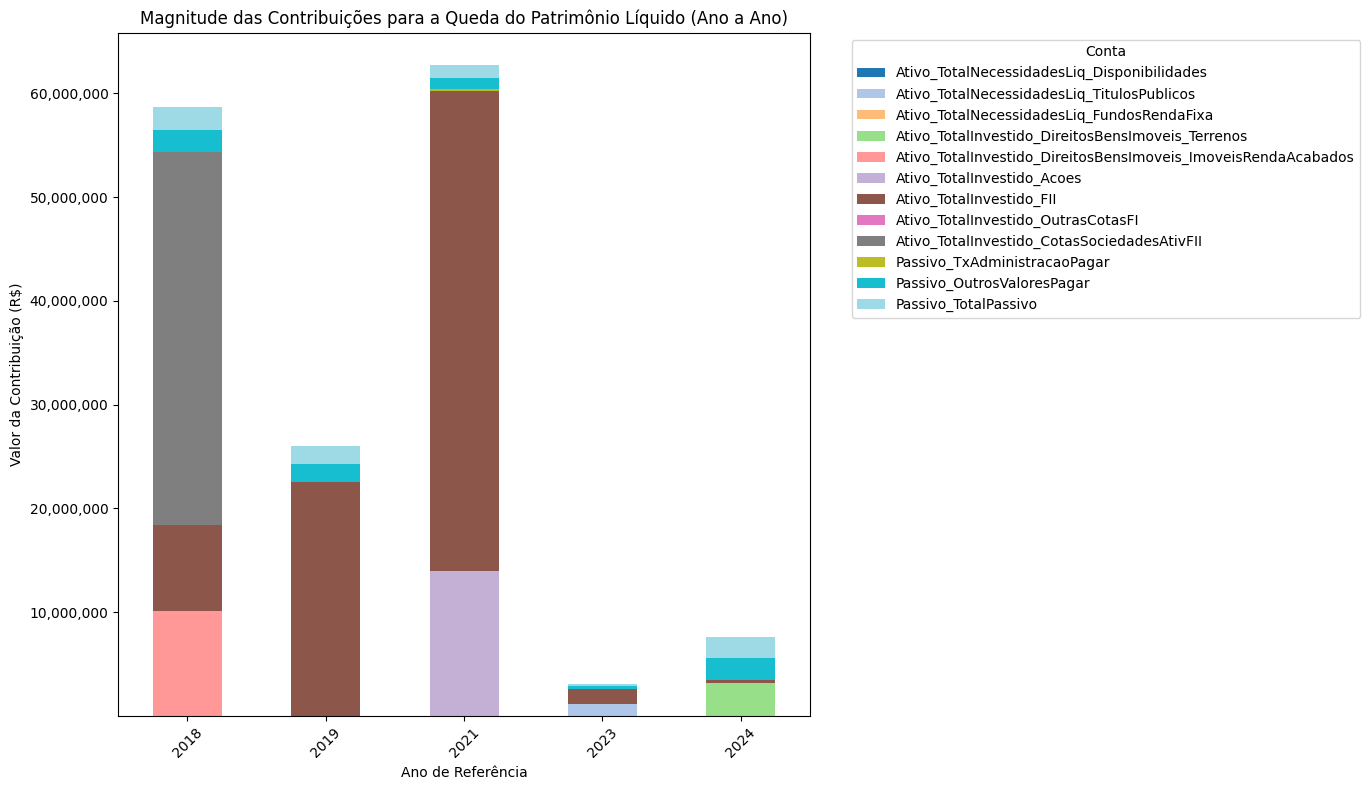

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mticker
import numpy as np

# Nome do arquivo CSV do df_visual transposto
NOME_ARQUIVO_DIFERENCA = f"fnet_subcontas_variacao_{CNPJ_FUNDO}.csv"

print(f"--- Gerando gráfico de contribuições para a queda do Patrimônio Líquido ---\n")

try:
    # Carrega o DataFrame de diferença (transposto) que contém os anos como colunas
    # e as contas como índice.
    df_diferenca_visual = pd.read_csv(NOME_ARQUIVO_DIFERENCA, index_col=0)

    # Assegura que todas as colunas de anos sejam numéricas para os cálculos
    for col in df_diferenca_visual.columns:
        df_diferenca_visual[col] = pd.to_numeric(df_diferenca_visual[col], errors='coerce')

    # Obtém a linha com a diferença do Patrimônio Líquido (PL) ao longo dos anos
    patrimonio_liquido_diff_row = df_diferenca_visual.loc['Mensal_Resumo_PatrimonioLiquido']

    # Identifica os anos em que houve queda no Patrimônio Líquido (valores negativos)
    # Filtra valores NaN, pois representam anos sem dados para diferença
    years_of_decrease = patrimonio_liquido_diff_row[patrimonio_liquido_diff_row < 0].dropna().index.tolist()

    if not years_of_decrease:
        print("Não houve queda no Patrimônio Líquido em nenhum ano para análise de contribuições.")
    else:
        # Filtra o DataFrame de diferenças para incluir apenas os anos de queda
        df_decreases_years = df_diferenca_visual[years_of_decrease]

        # Exclui a própria linha do Patrimônio Líquido do conjunto de contas contribuintes
        # e outras colunas de identificação se houverem
        relevant_accounts = df_decreases_years.index.drop(['Mensal_Resumo_PatrimonioLiquido', 'Gerais_NomeFundo'], errors='ignore')

        # Cria um DataFrame para armazenar as contribuições para a queda
        contributions_df = pd.DataFrame(index=relevant_accounts, columns=years_of_decrease)

        # Itera sobre os anos de queda e as contas relevantes para identificar as contribuições
        for year in years_of_decrease:
            for account in relevant_accounts:
                change = df_decreases_years.loc[account, year]

                # Uma queda no PL pode ser causada por:
                # 1. Diminuição de um Ativo (mudança negativa)
                # 2. Aumento de um Passivo (mudança positiva)
                if pd.notna(change):
                    if 'Ativo_' in account and change < 0:
                        # Contribuição de um ativo que diminuiu (pega o valor absoluto)
                        contributions_df.loc[account, year] = abs(change)
                    elif 'Passivo_' in account and change > 0:
                        # Contribuição de um passivo que aumentou
                        contributions_df.loc[account, year] = change
                    else:
                        contributions_df.loc[account, year] = 0 # Não contribui para a queda, ou a aumenta
                else:
                    contributions_df.loc[account, year] = 0

        # Converte todas as colunas para numérico e preenche NaNs com 0 (caso existam)
        contributions_df = contributions_df.apply(pd.to_numeric, errors='coerce').fillna(0)

        # Transpõe o DataFrame para que os anos sejam o índice e as contas as colunas (formato para o stacked bar)
        contributions_df_transposed = contributions_df.T

        # Remove colunas (contas) que não tiveram nenhuma contribuição significativa nos anos de queda
        contributions_df_final = contributions_df_transposed.loc[:, (contributions_df_transposed != 0).any(axis=0)]

        if contributions_df_final.empty:
            print("Não foram encontradas contas que contribuíram significativamente para a queda do Patrimônio Líquido nos anos identificados.")
        else:
            # Garante que o índice (anos) seja do tipo int e esteja ordenado
            contributions_df_final.index = contributions_df_final.index.astype(int)
            contributions_df_final = contributions_df_final.sort_index()

            # Plotting the stacked bar chart
            fig, ax = plt.subplots(figsize=(14, 8))

            # Gera um mapa de cores para distinguir as contas
            num_accounts_to_plot = contributions_df_final.shape[1]
            colors = plt.cm.get_cmap('tab20', num_accounts_to_plot)

            contributions_df_final.plot(kind='bar', stacked=True, ax=ax, color=[colors(i) for i in range(num_accounts_to_plot)])

            ax.set_title('Magnitude das Contribuições para a Queda do Patrimônio Líquido (Ano a Ano)')
            ax.set_xlabel('Ano de Referência')
            ax.set_ylabel('Valor da Contribuição (R$)')
            ax.tick_params(axis='x', rotation=45)

            # Formata o eixo Y para ter separador de milhares
            ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

            plt.legend(title='Conta', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

except FileNotFoundError:
    print(f"\n[ERRO] Arquivo '{NOME_ARQUIVO_DIFERENCA}' não encontrado.")
    print("Certifique-se de que o arquivo foi salvo no passo anterior.")
except Exception as e:
    print(f"\n[ERRO] Ocorreu um erro durante a geração do gráfico: {e}")

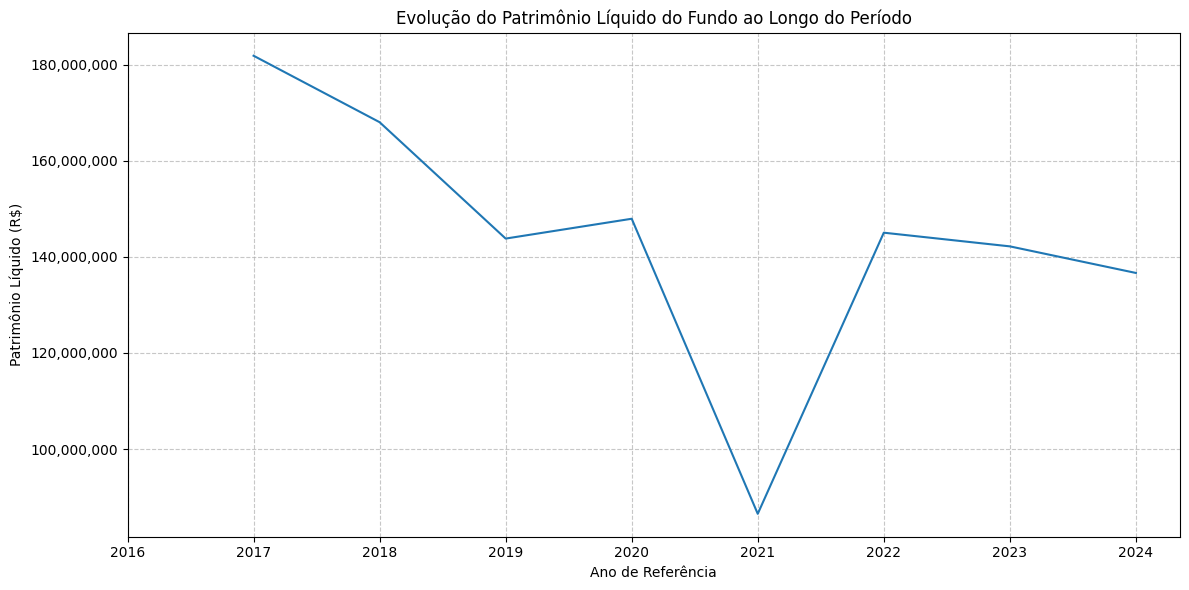

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as mticker

# Assegura que df_final está carregado. Se o kernel foi resetado,
# podemos recarregar do arquivo consolidado.
# NOME_ARQUIVO_FINAL é 'fnet_consolidado_subcontas_sem_zero_13555918000149_FINAL.csv'
if 'df_final' not in locals():
    NOME_ARQUIVO_FINAL = f"fnet_consolidado_subcontas_sem_zero_{CNPJ_FUNDO}_FINAL.csv"
    df_final = pd.read_csv(NOME_ARQUIVO_FINAL)

# Garante que 'Ano_Referencia' seja numérico para ordenação e plotagem corretas
df_final['Ano_Referencia'] = pd.to_numeric(df_final['Ano_Referencia'])

# Ordena o DataFrame pelo ano para garantir a linha do tempo correta
df_sorted = df_final.sort_values(by='Ano_Referencia')

plt.figure(figsize=(12, 6))
sns.lineplot(
x='Ano_Referencia',
y='Mensal_Resumo_PatrimonioLiquido',
data=df_sorted
)

plt.title('Evolução do Patrimônio Líquido do Fundo ao Longo do Período')
plt.xlabel('Ano de Referência')
plt.ylabel('Patrimônio Líquido (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_sorted['Ano_Referencia'].unique()) # Garante que todos os anos sejam exibidos

# Formata o eixo Y para ter separador de milhares usando StrMethodFormatter
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}')) # Adiciona separador de milhares

plt.tight_layout()
plt.show()